In [1]:
import loompy as lp
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pdir = "/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/"
MODULE_PATH = pdir+"processed-data/09_DEG_GRN/AUCell_modules/"

In [38]:
def extract_aucell(cluster):
    
    lf = lp.connect(MODULE_PATH+"spe-n119_seurat-label-"+cluster+"_13844-genes_no-lowUMI_logcounts_modules-top20-Fadjp05_AUCell-fixed-thold-05.loom", mode='r+', validate=False)
    auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
    cell_mtx = pd.DataFrame({"seurat_label": lf.ca.seurat_label, "smoothed_k9_1663": lf.ca.smoothed_k9_1663, #"custom_cluster": cluster,
                             "sex": lf.ca.sex, "condition": lf.ca.condition, "nGene": lf.ca.nGene, "nUMI": lf.ca.nUMI}, index=lf.ca.CellID)
    lf.close()
    
    #signature_column_names = list(auc_mtx.select_dtypes('number').columns)
    #signature_column_names = list(map(lambda s: s[12:], signature_column_names))
    #auc_mtx.columns = signature_column_names
    
    return auc_mtx, cell_mtx

In [39]:
auc_mv, cell_mv = extract_aucell("Micro.Vasc")
auc_ast, cell_ast = extract_aucell("Astro")
auc_l23, cell_l23 = extract_aucell("L2.3")
auc_l4, cell_l4 = extract_aucell("L4")
auc_inh, cell_inh = extract_aucell("Inhb")
auc_l5, cell_l5 = extract_aucell("L5")
auc_l6, cell_l6 = extract_aucell("L6")
auc_wm, cell_wm = extract_aucell("Oligo")

In [40]:
auc_all = pd.concat([auc_mv, auc_ast, auc_l23, 
                     auc_l4, auc_inh, auc_l5, auc_l6, auc_wm])
cell_all = pd.concat([cell_mv, cell_ast, cell_l23, 
                      cell_l4, cell_inh, cell_l5, cell_l6, cell_wm])

In [41]:
import numpy as np
auc_corr = np.corrcoef(auc_all.T)
corrDF = pd.DataFrame(auc_corr, index=auc_all.columns, columns= auc_all.columns)
corrDF.head()

,A2M(+),ADAMTS1(+),ANGPTL4(+),APBB1(+),APLP1(+),APOE(+),AQP1(+),ARF1(+),ATP1A3(+),ATP1B1(+),...,TSC22D1(+),TTYH1(+),UBC(+),UQCR10(+),UQCRB(+),UQCRH(+),UQCRQ(+),YWHAZ(+),ZFP36(+),ATP1B1(-)
A2M(+),1.000000,0.428097,0.082068,-0.277914,-0.188191,0.002440,0.159553,-0.291898,-0.325328,-0.322442,...,-0.334967,0.008035,-0.315882,-0.262971,-0.145409,-0.281407,-0.244451,-0.360559,0.224325,-0.194884
ADAMTS1(+),0.428097,1.000000,0.210954,-0.165104,-0.074340,0.054792,0.134280,-0.166999,-0.196513,-0.193316,...,-0.187176,0.033015,-0.155127,-0.163566,-0.065773,-0.172397,-0.152488,-0.206556,0.428711,-0.101341
ANGPTL4(+),0.082068,0.210954,1.000000,-0.101015,0.006455,0.246058,0.271537,-0.117012,-0.172760,-0.166909,...,-0.148396,0.202279,-0.113093,-0.133086,-0.055781,-0.148875,-0.129677,-0.169573,0.624908,-0.068061
APBB1(+),-0.277914,-0.165104,-0.101015,1.000000,0.410513,0.154646,-0.235503,0.859975,0.773675,0.593952,...,0.739210,0.142124,0.681169,0.433523,0.210108,0.443685,0.375538,0.769714,-0.145973,0.436661
APLP1(+),-0.188191,-0.074340,0.006455,0.410513,1.000000,0.277989,0.173364,0.385336,0.255437,0.312651,...,0.366578,0.185158,0.554629,0.259091,0.396972,0.265077,0.257731,0.439998,0.007537,0.374700


In [42]:
corrDF.to_csv(pdir+"processed-data/09_DEG_GRN/spe-n119_13844-no-lowUMI_logcounts_modules-top20-Fadjp05_AUCell-correlation.csv")

/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


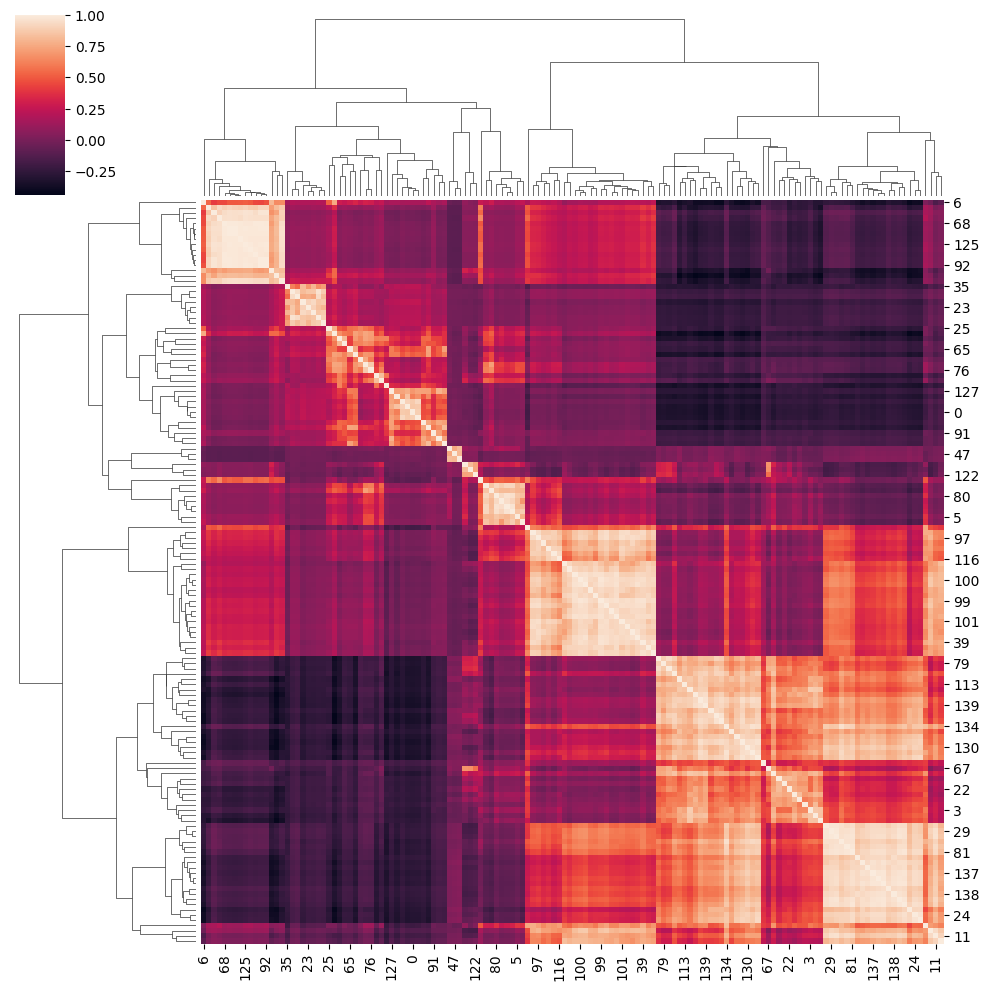

In [43]:
sns.clustermap(auc_corr)

In [8]:
joined_all = pd.concat([auc_all, cell_all], axis=1)
joined_all.shape

(513200, 148)

In [9]:
joined_all.to_csv(pdir+"processed-data/09_DEG_GRN/spe-n119_13844-no-lowUMI_logcounts_modules-top20-Fadjp05_AUCell.csv")

In [10]:
transfer_bright = {'Micro.Vasc': "#911223", 'Astro': "#cfa45c", 'L2.3': "#088F8F", 'L4': "#c2cfcf",
                   'Inhb': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'Oligo': "#D1C4B0"}
smoothed_bright = {'Vasc': "#911223", 'L1': "#cfa45c", 'L2': "#5D9940", 'L3.4': "#5095CD",
                  'GABA': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'WM': "#D1C4B0"}

In [11]:
joined_precast = joined_all.loc[-joined_all['smoothed_k9_1663'].isin(['Vasc','GABA'])]
joined_precast.shape

(508372, 148)

In [12]:
sns.set_theme(font_scale=.7)

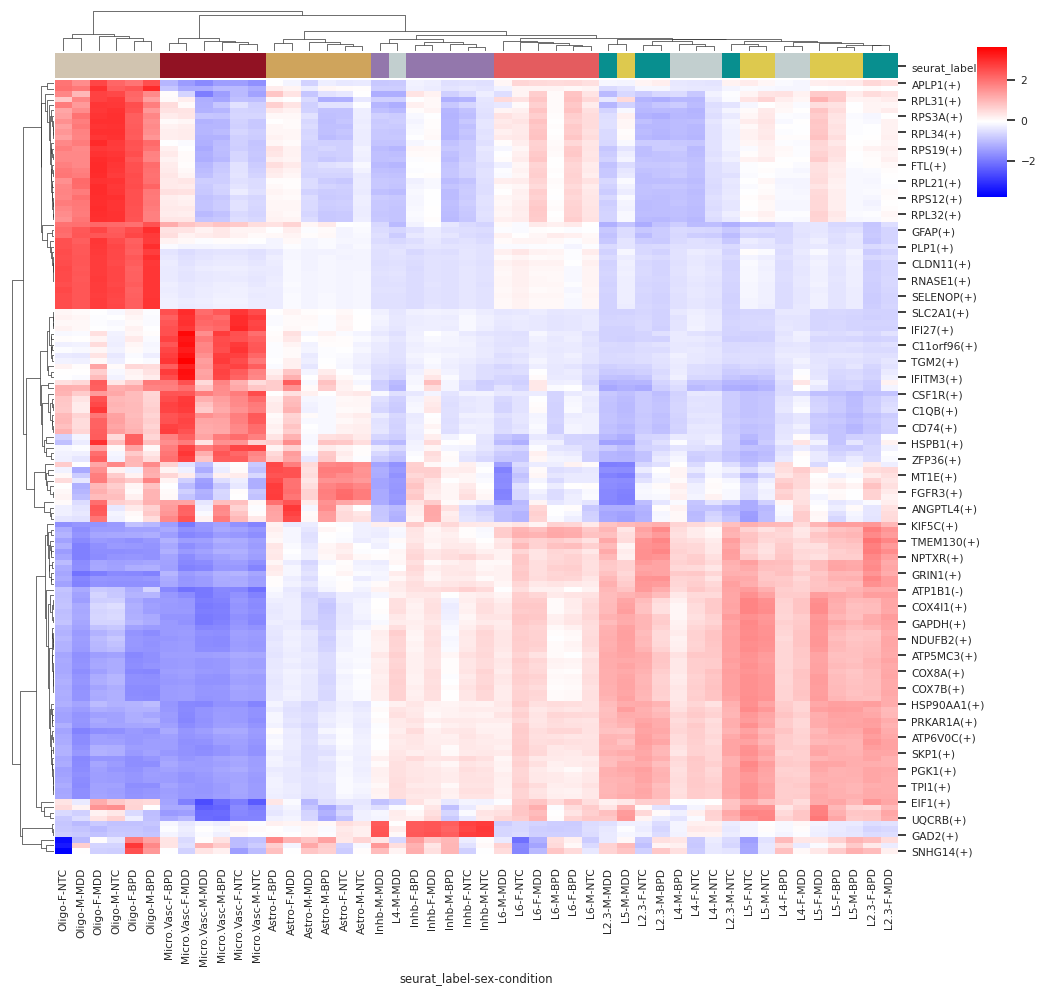

In [13]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['seurat_label'] = [x[0] for x in df_means.index]
row_colors = colors_df['seurat_label'].map(transfer_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

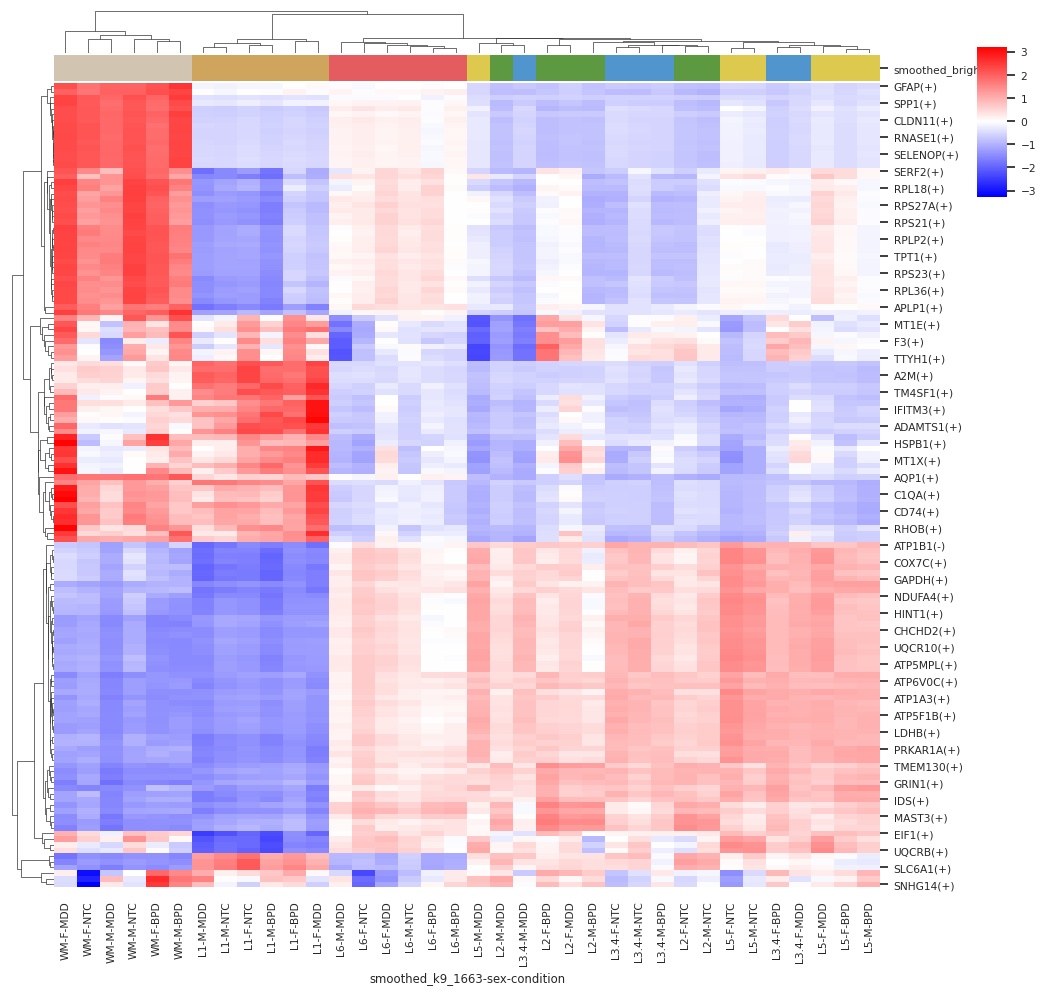

In [14]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['smoothed_k9_1663','sex','condition']]
df_scores = df_scores.loc[-df_scores['smoothed_k9_1663'].isin(['Vasc','GABA'])]
df_means = df_scores.groupby(by=['smoothed_k9_1663','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['smoothed_bright'] = [x[0] for x in df_means.index]
row_colors = colors_df['smoothed_bright'].map(smoothed_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

In [15]:
laDEGs = pd.read_csv(pdir+"processed-data/07_dx_DE/layer-adjusted-pc3-age-nspots_smoothed-k9-1663_dx-sex_degs-F-test-t-test.csv")
lrDEGs = pd.read_csv(pdir+"processed-data/07_dx_DE/layer-restricted-pc3-age-nspots_smoothed-k9-1663_dx-sex_degs-F-test-t-test.csv")
smDEGs = list(set(pd.concat([laDEGs.gene_name[laDEGs.n_ttest_sig>0], lrDEGs.gene_name[lrDEGs.n_ttest_sig>0]])))

laDEGs = pd.read_csv(pdir+"processed-data/07_dx_DE/layer-adjusted-pc3-age-nspots_seurat-pc30_dx-sex_degs-F-test-t-test.csv")
lrDEGs = pd.read_csv(pdir+"processed-data/07_dx_DE/layer-restricted-pc3-age-nspots_seurat-pc30_dx-sex_degs-F-test-t-test.csv")
seDEGs = list(set(pd.concat([laDEGs.gene_name[laDEGs.n_ttest_sig>0], lrDEGs.gene_name[lrDEGs.n_ttest_sig>0]])))

mbvDEGs = list(set(smDEGs).union(set(seDEGs)))
len(mbvDEGs)

503

In [16]:
mbvDEGs_up = [item+"(+)" for item in mbvDEGs]
mbvDEGs_dn = [item+"(-)" for item in mbvDEGs]

mbvDEGs_dir= mbvDEGs_up+mbvDEGs_dn
len(mbvDEGs_dir)

1006

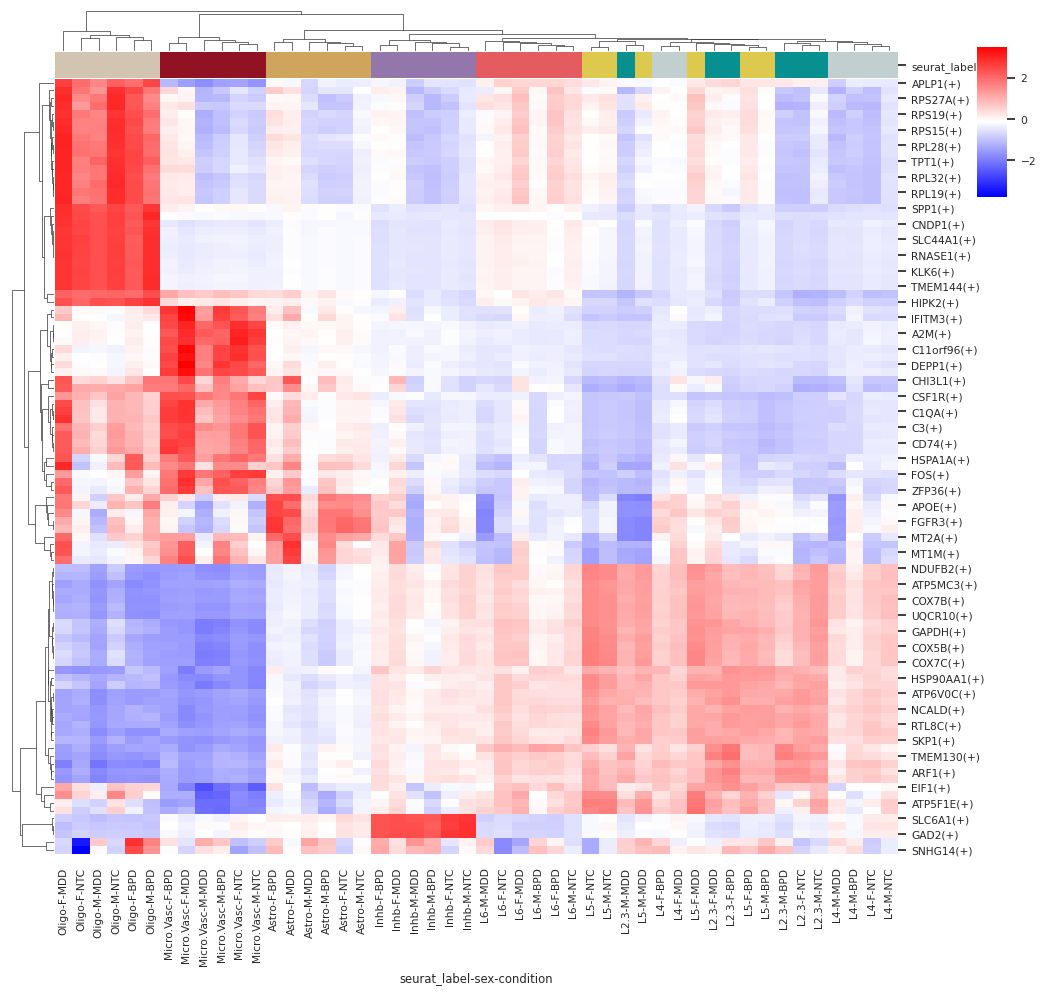

In [17]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

# subset to columns that are DEGs
df_means = df_means.loc[:,df_means.columns.isin(mbvDEGs_dir)]

colors_df = pd.DataFrame(index=df_means.index)
colors_df['seurat_label'] = [x[0] for x in df_means.index]
row_colors = colors_df['seurat_label'].map(transfer_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

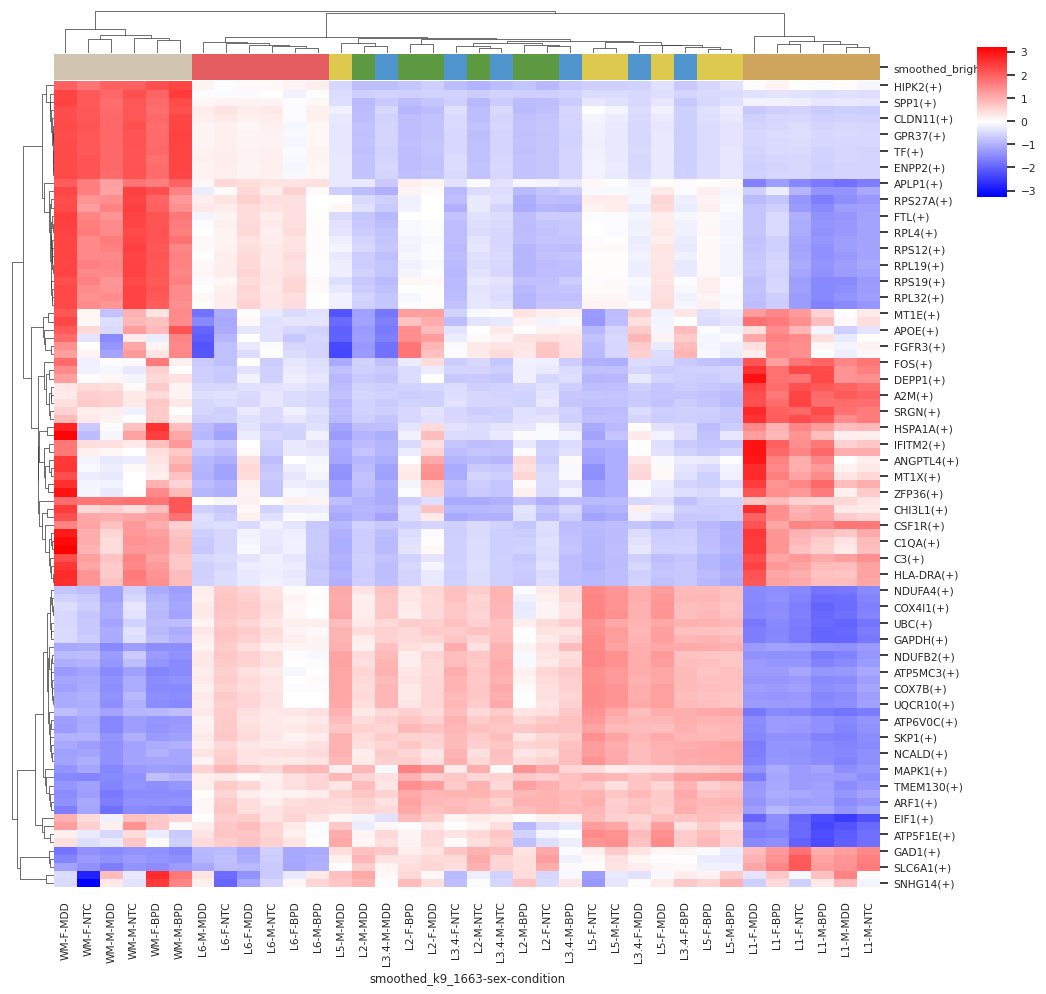

In [18]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['smoothed_k9_1663','sex','condition']]
df_scores = df_scores.loc[-df_scores['smoothed_k9_1663'].isin(['Vasc','GABA'])]
df_means = df_scores.groupby(by=['smoothed_k9_1663','sex','condition']).mean()

# subset to columns that are DEGs
df_means = df_means.loc[:,df_means.columns.isin(mbvDEGs_dir)]

colors_df = pd.DataFrame(index=df_means.index)
colors_df['smoothed_bright'] = [x[0] for x in df_means.index]
row_colors = colors_df['smoothed_bright'].map(smoothed_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

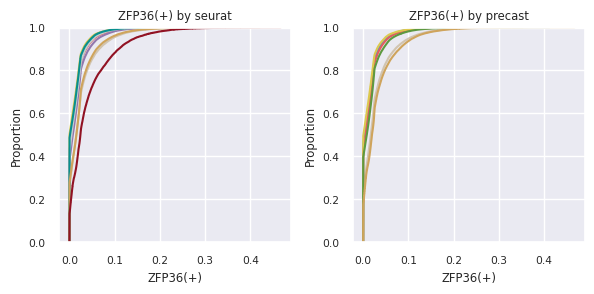

In [19]:
gene1 = "ZFP36(+)"

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

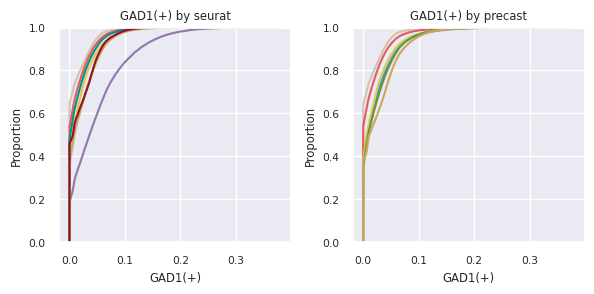

In [20]:
gene1 = "GAD1(+)"

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

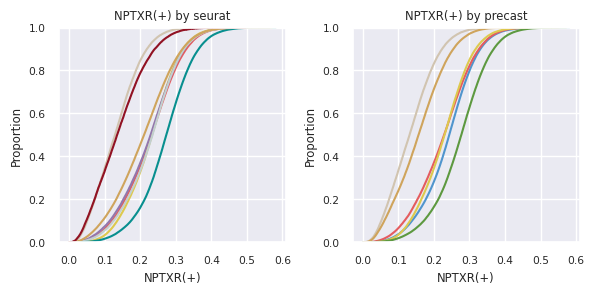

In [21]:
gene1 = "NPTXR(+)" #

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

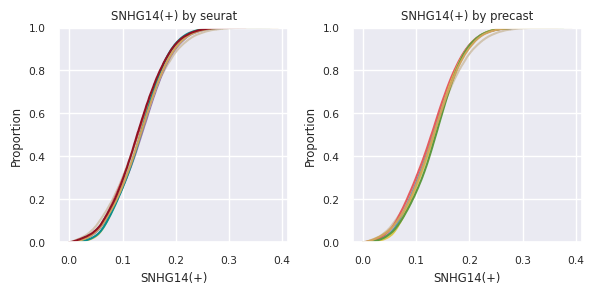

In [26]:
gene1 = "SNHG14(+)" #

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

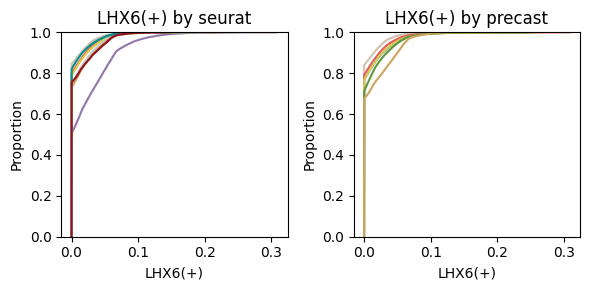

In [50]:
gene1 = "LHX6(+)" #inhb

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

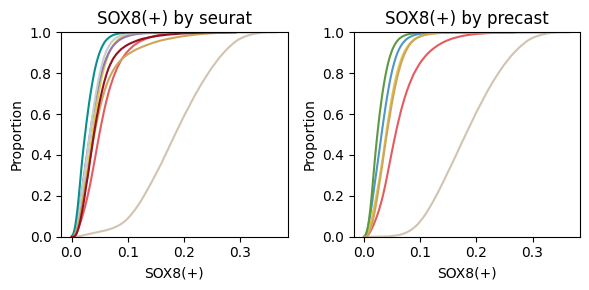

In [51]:
gene1 = "SOX8(+)" #OLIG

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

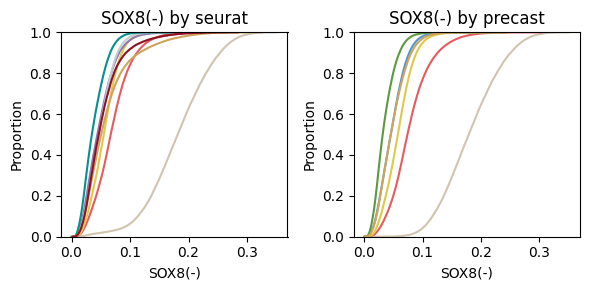

In [52]:
gene1 = "SOX8(-)" #OLIG

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

In [53]:
len(auc_all.columns)

42

In [54]:
auc_all.columns

Index(['ARX(+)', 'ATF3(+)', 'ATF3(-)', 'BCL6(-)', 'CEBPB(+)', 'CEBPB(-)',
       'CEBPD(-)', 'CUX2(-)', 'DLX1(-)', 'ETS2(+)', 'ETS2(-)', 'FOS(-)',
       'FOSB(+)', 'FOSB(-)', 'IRF9(+)', 'IRF9(-)', 'JUN(+)', 'JUNB(+)',
       'JUND(-)', 'KLF2(+)', 'KLF4(+)', 'LHX2(+)', 'LHX6(+)', 'MAFF(+)',
       'MBNL2(-)', 'NEUROD1(+)', 'NPAS4(+)', 'NR2F2(+)', 'NR2F2(-)',
       'SOX10(+)', 'SOX10(-)', 'SOX2(+)', 'SOX2(-)', 'SOX8(+)', 'SOX8(-)',
       'SOX9(+)', 'SOX9(-)', 'SREBF1(+)', 'SREBF1(-)', 'THRA(-)', 'ZBTB7A(+)',
       'ZBTB7A(-)'],
      dtype='object')

<Axes: xlabel='CEBPD(-)', ylabel='Density'>

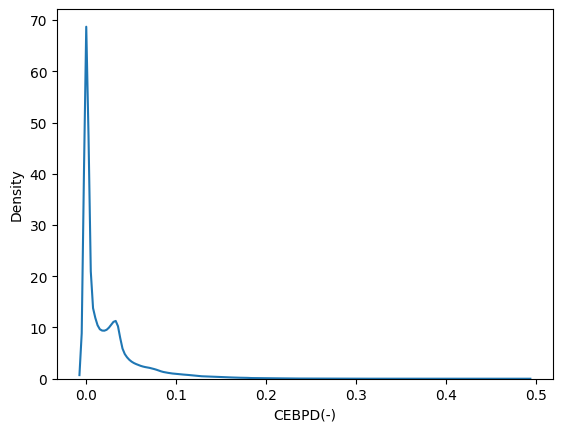

In [18]:
sns.kdeplot(data=joined_all, x="CEBPD(-)")

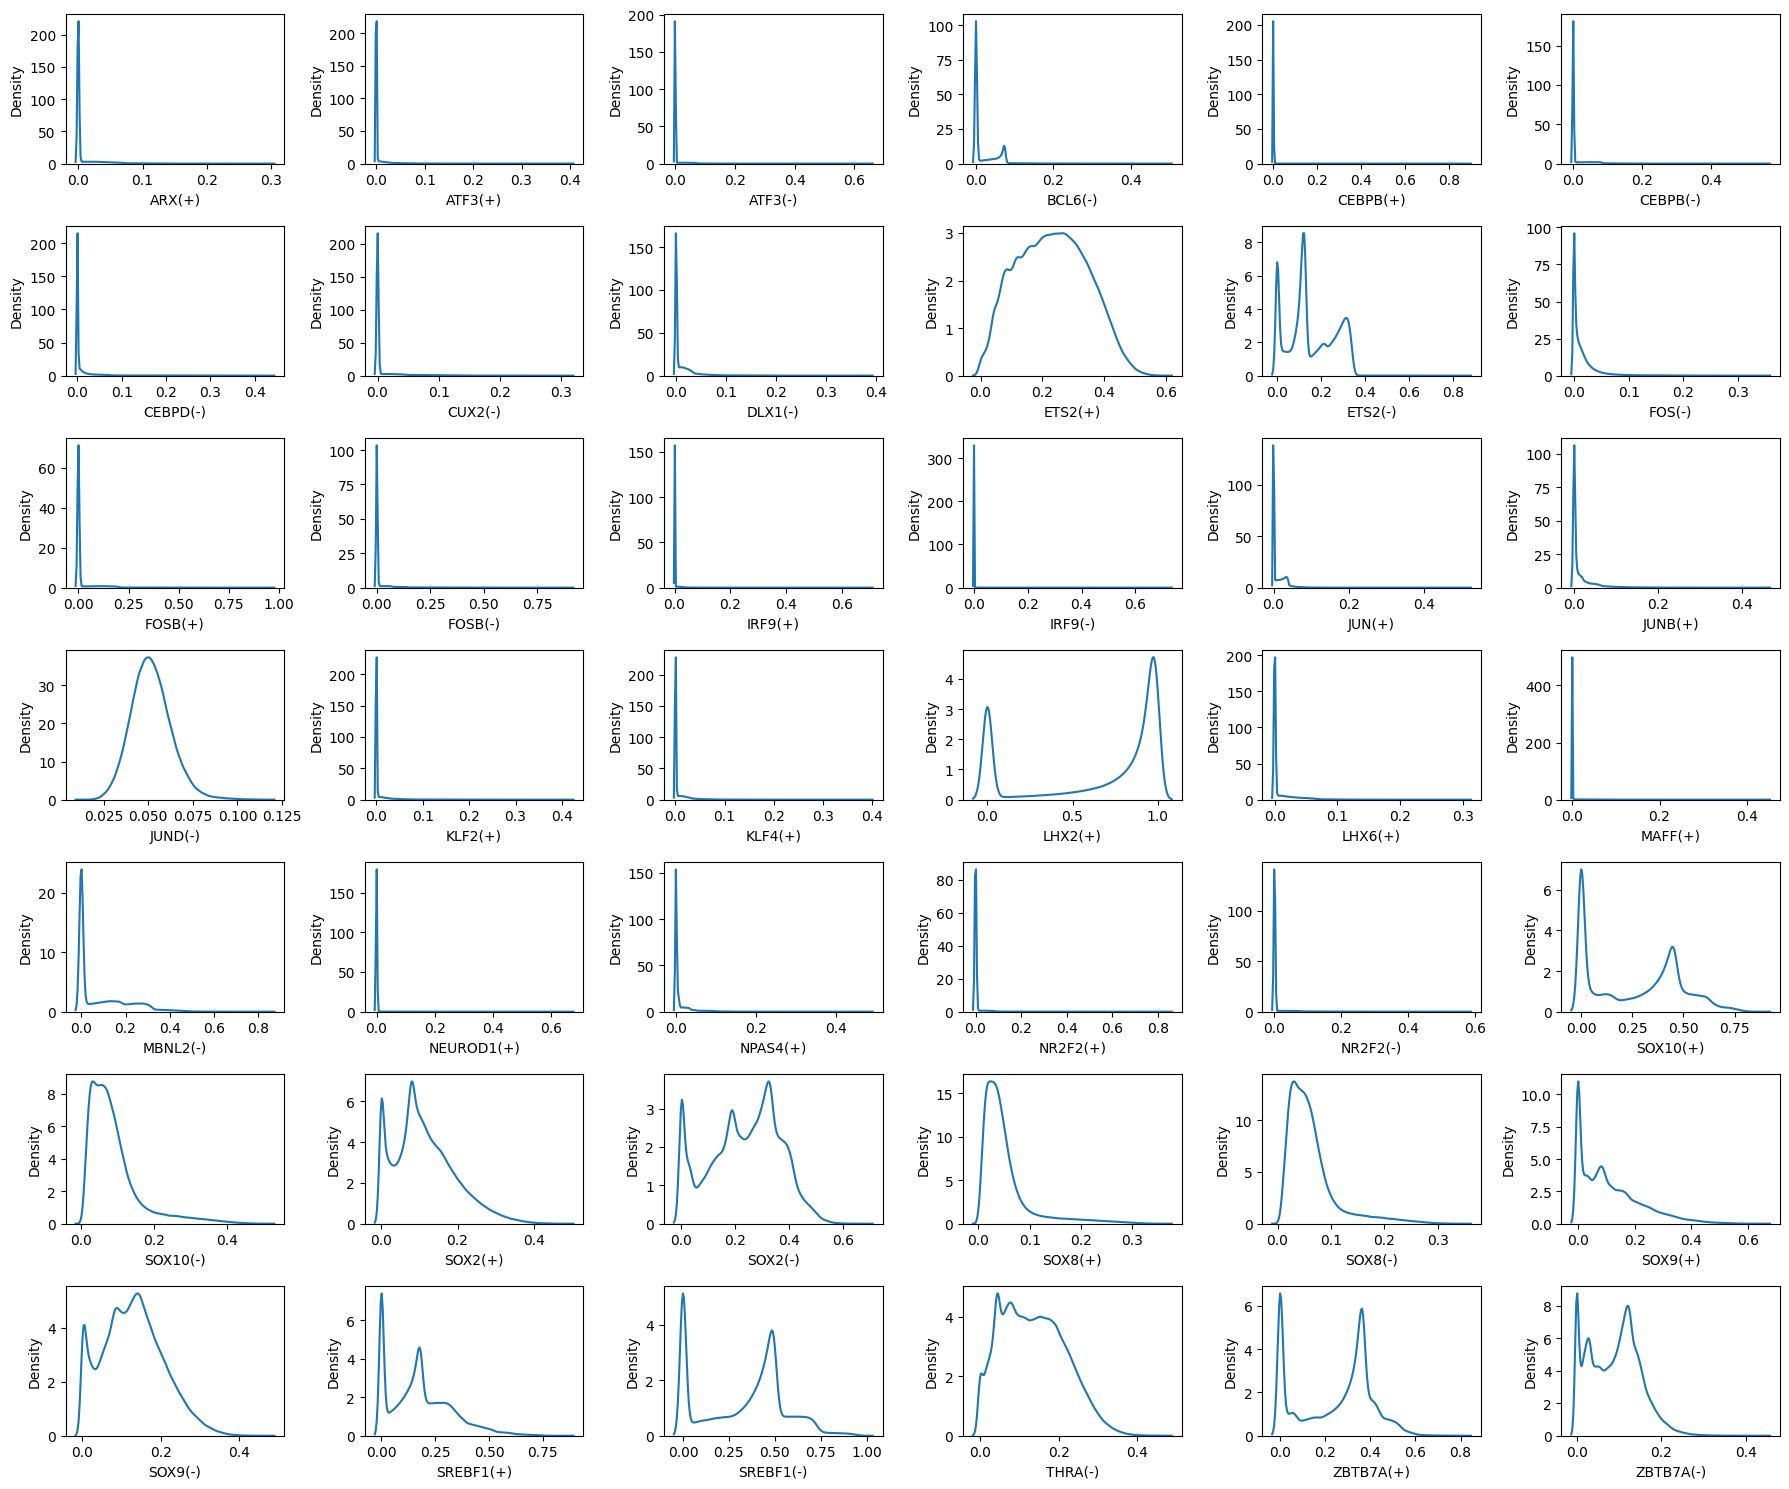

In [56]:
fig, axs = plt.subplots(7, 6, figsize=(18, 15))

axs_flat = axs.flatten()

for i in range(42):
    gene1 = auc_all.columns[i]
    
    sns.kdeplot(data=joined_all, x=gene1, ax=axs_flat[i])

plt.tight_layout()
plt.show()

In [24]:
#unimodal: THRB, GTF2I
# from source code this is their thresholding method for unimodal

auc_all['GTF2I(+)'].mean() + 2.0 * auc_all['GTF2I(+)'].std()

0.15615375083348051

In [40]:
from pyscenic.binarization import binarize

In [65]:
bin_all, thresholds_all = binarize(auc_scale)

/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic

In [54]:
def plot_binarization(
    auc_mtx: pd.DataFrame, regulon_name: str, threshold: float, bins: int = 200, ax=None
) -> None:
    """
    Plot the "binarization" process for the given regulon.

    :param auc_mtx: The dataframe with the AUC values for all cells and regulons (n_cells x n_regulons).
    :param regulon_name: The name of the regulon.
    :param bins: The number of bins to use in the AUC histogram.
    :param threshold: The threshold to use for binarization.
    """
    if ax is None:
        ax = plt.gca()
    sns.histplot(auc_mtx[regulon_name], ax=ax, #norm_hist=True, 
                 bins=bins)

    ylim = ax.get_ylim()
    ax.plot([threshold] * 2, ylim, "r:")
    ax.set_ylim(ylim)
    ax.set_xlabel("AUC")
    ax.set_ylabel("#")
    ax.set_title(regulon_name)


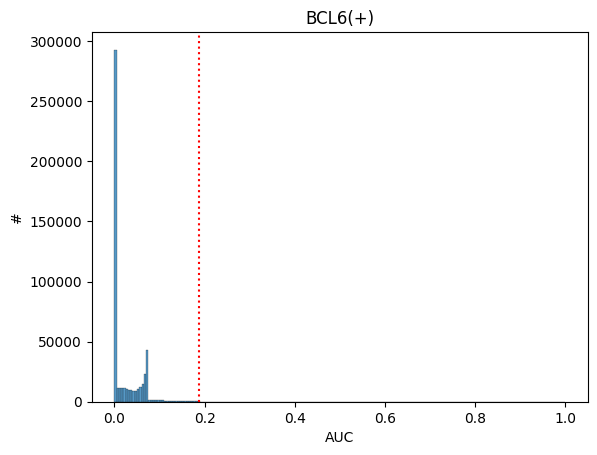

In [66]:
plot_binarization(auc_scale, "BCL6(+)", thresholds_all['BCL6(+)'])

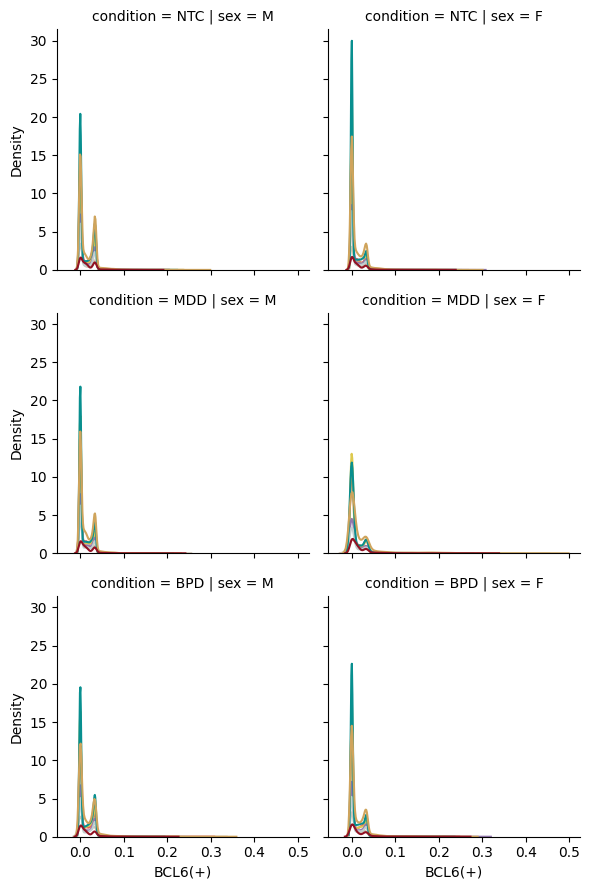

In [37]:
g = sns.FacetGrid(joined_all, col="sex",  row="condition")
g.map_dataframe(sns.kdeplot, x="BCL6(+)", hue="seurat_label", palette=transfer_bright)

In [34]:
joined_all['BCL6(+)']

TAGAATAGCCGATGAA-1_V13F27-338_A1    0.000000
CAACCTACCGAGCAGT-1_V13F27-338_A1    0.009600
GTCAACCAGGCCTATA-1_V13F27-338_A1    0.004672
CTAGGTCTGAAGGAAT-1_V13F27-338_A1    0.000000
CACCGTATCCCATCCG-1_V13F27-338_A1    0.007701
                                      ...   
CCAGTCTAGACGGCGC-1_V13B23-282_D1    0.000000
TCGCTTTAAACGTTTG-1_V13B23-282_D1    0.001027
AGTTACTCTATCGTGG-1_V13B23-282_D1    0.015813
GTGGCTGTTTCTGTTC-1_V13B23-282_D1    0.001643
CGTCGGATAGTGTTGA-1_V13B23-282_D1    0.016737
Name: BCL6(+), Length: 513200, dtype: float64